# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Ricerra, Myke Lawrence
- _Student No._: 2024-07203
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/4_problem.png" alt="Mean Absolute Error vs. Step Size" width=45%>
Plot showing the relation of step size and mean absolute error of different difference formula for solving first derivative.

### Report discussion

The plot shows that there is a positive correlation between step size and mean absolute error: the smaller the step size, the lower the mean absolute error. The central method shows a much steeper slope compared to the backward and forward methods. This is expected, as the log-scaled plot shows that forward and backward differences exhibit first-order accuracy ($\mathcal{O}(h)$), whereas the central difference exhibits second-order accuracy ($\mathcal{O}(h^2)$). The higher the order of accuracy, the faster the error (represented by the mean absolute error) decreases when we decrease the step size (represented by the variable $h$).

When the first or last data point is missing, it is more appropriate to use non-central difference formulas. Forward difference is used when the first data point (or past data) does not exist, and backward difference is used for the opposite situation. The central difference formula is suitable everywhere else and is more appropriate for high-precision calculations. In all cases, smaller step sizes yield more accurate results (as long as they are not small enough for catastrophic cancellation to occur)

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

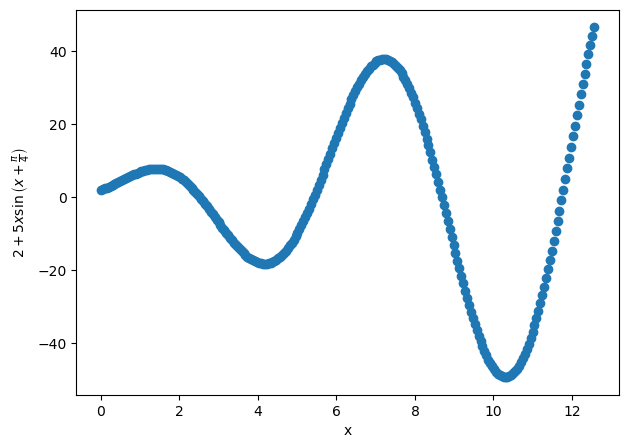

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [3]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x_1 = np.linspace(0, 4*np.pi, 257)
x_2 = np.linspace(0, 4*np.pi, 513)
x_3 = np.linspace(0, 4*np.pi, 1025)
x_4 = np.linspace(0, 4*np.pi, 65)

In [4]:
def dx_backward(x):
    delta_x = (np.roll(x,1)-x)[1:]
    delta_f = (np.roll(f_0(x),1)-f_0(x))[1:]
    return delta_f/delta_x

def dx_forward(x):
    delta_x = (np.roll(x,-1)-x)[:-1]
    delta_f = (np.roll(f_0(x),-1)-f_0(x))[:-1]
    return delta_f/delta_x

def dx_central(x):
    delta_x = (np.roll(x,-1)-np.roll(x,1))[1:-1]
    delta_f = (np.roll(f_0(x),-1)-np.roll(f_0(x),1))[1:-1]
    return delta_f/delta_x

dx_anal = lambda x: 5*(np.sin(1*x+np.pi/4)+1*x*np.cos(1*x+np.pi/4))

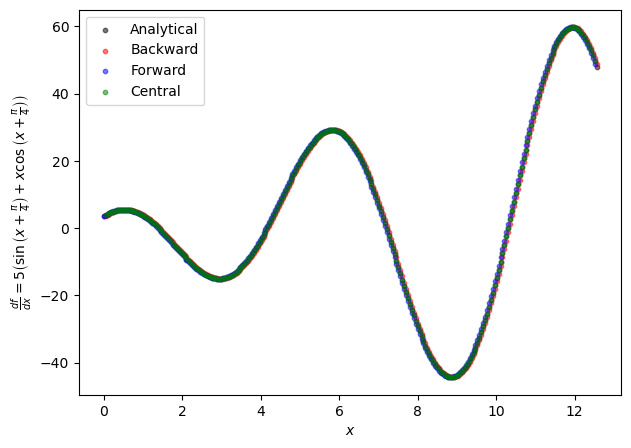

In [5]:
fig, dx1 = plt.subplots(figsize=(7,5))
dx1.scatter(x_1, dx_anal(x_1), c='black', s=10, alpha=0.5, label='Analytical')
dx1.scatter(x_1[1:], dx_backward(x_1), c='red', s=10, alpha=0.5, label='Backward')
dx1.scatter(x_1[:-1], dx_forward(x_1), c='blue', s=10, alpha=0.5, label='Forward')
dx1.scatter(x_1[1:-1], dx_central(x_1), c='green', s=10, alpha=0.5, label='Central')
dx1.set_xlabel(r'$x$')
dx1.set_ylabel(r"$\frac{df}{dx}=5\left(\sin\left(x+\frac{\pi}{4}\right)+x\cos\left(x+\frac{\pi}{4}\right)\right)$")
dx1.legend()
fig.show()

In [6]:
def mae(x, diff):
    if diff == 'backward':
        return np.sum(np.abs(dx_backward(x)-dx_anal(x)[1:]))/len(x[1:])
    elif diff == 'forward':
        return np.sum(np.abs(dx_forward(x)-dx_anal(x)[:-1]))/len(x[:-1])
    elif diff == 'central':
        return np.sum(np.abs(dx_central(x)-dx_anal(x)[1:-1]))/len(x[1:-1])
    else: 
        return 
        print ("Difference formula: 'backward', 'forward', or 'central'")

print("For x with 256 points:")
print(f"Mean absolute error of backward difference formula is {mae(x_1, 'backward')}")
print(f"Mean absolute error of forward difference formula is {mae(x_1, 'forward')}")
print(f"Mean absolute error of central difference formula is {mae(x_1, 'central')}")

For x with 256 points:
Mean absolute error of backward difference formula is 0.5005317898124999
Mean absolute error of forward difference formula is 0.49955430148550295
Mean absolute error of central difference formula is 0.00965219776868435


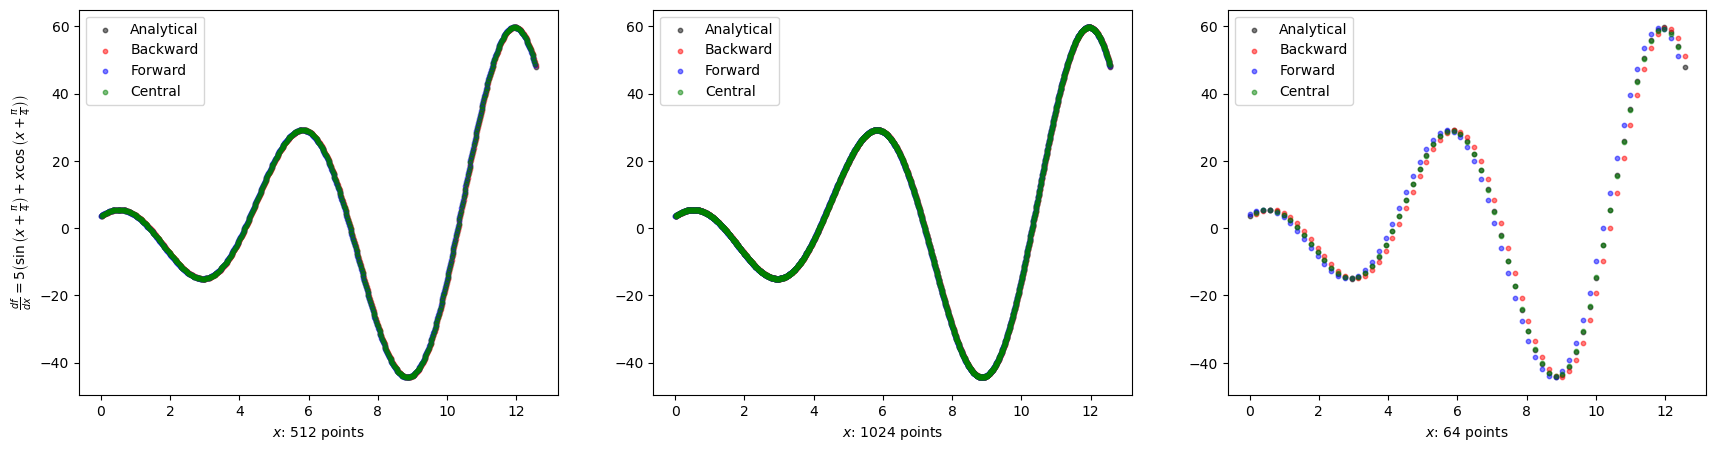

In [7]:
fig, dx2 = plt.subplots(1, 3, figsize=(21,5))
dx2[0].scatter(x_2, dx_anal(x_2), c='black', s=10, alpha=0.5, label='Analytical')
dx2[0].scatter(x_2[1:], dx_backward(x_2), c='red', s=10, alpha=0.5, label='Backward')
dx2[0].scatter(x_2[:-1], dx_forward(x_2), c='blue', s=10, alpha=0.5, label='Forward')
dx2[0].scatter(x_2[1:-1], dx_central(x_2), c='green', s=10, alpha=0.5, label='Central')
dx2[0].set_xlabel(r'$x$: 512 points')
dx2[0].set_ylabel(r"$\frac{df}{dx}=5\left(\sin\left(x+\frac{\pi}{4}\right)+x\cos\left(x+\frac{\pi}{4}\right)\right)$")
dx2[0].legend()
dx2[1].scatter(x_3, dx_anal(x_3), c='black', s=10, alpha=0.5, label='Analytical')
dx2[1].scatter(x_3[1:], dx_backward(x_3), c='red', s=10, alpha=0.5, label='Backward')
dx2[1].scatter(x_3[:-1], dx_forward(x_3), c='blue', s=10, alpha=0.5, label='Forward')
dx2[1].scatter(x_3[1:-1], dx_central(x_3), c='green', s=10, alpha=0.5, label='Central')
dx2[1].set_xlabel(r'$x$: 1024 points')
dx2[1].legend()
dx2[2].scatter(x_4, dx_anal(x_4), c='black', s=10, alpha=0.5, label='Analytical')
dx2[2].scatter(x_4[1:], dx_backward(x_4), c='red', s=10, alpha=0.5, label='Backward')
dx2[2].scatter(x_4[:-1], dx_forward(x_4), c='blue', s=10, alpha=0.5, label='Forward')
dx2[2].scatter(x_4[1:-1], dx_central(x_4), c='green', s=10, alpha=0.5, label='Central')
dx2[2].set_xlabel(r'$x$: 64 points')
dx2[2].legend()
fig.show()

In [8]:
print("For x with 512 points:")
print(f"Mean absolute error of backward difference formula is {mae(x_2, 'backward')}")
print(f"Mean absolute error of forward difference formula is {mae(x_2, 'forward')}")
print(f"Mean absolute error of central difference formula is {mae(x_2, 'central')}")

print("For x with 1024 points:")
print(f"Mean absolute error of backward difference formula is {mae(x_3, 'backward')}")
print(f"Mean absolute error of forward difference formula is {mae(x_3, 'forward')}")
print(f"Mean absolute error of central difference formula is {mae(x_3, 'central')}")

print("For x with 64 points:")
print(f"Mean absolute error of backward difference formula is {mae(x_4, 'backward')}")
print(f"Mean absolute error of forward difference formula is {mae(x_4, 'forward')}")
print(f"Mean absolute error of central difference formula is {mae(x_4, 'central')}")

For x with 512 points:
Mean absolute error of backward difference formula is 0.2501680318952484
Mean absolute error of forward difference formula is 0.2499280443665739
Mean absolute error of central difference formula is 0.002415149573606673
For x with 1024 points:
Mean absolute error of backward difference formula is 0.12505637456847615
Mean absolute error of forward difference formula is 0.12499594287813948
Mean absolute error of central difference formula is 0.0006040180408417509
For x with 64 points:
Mean absolute error of backward difference formula is 2.004257825364945
Mean absolute error of forward difference formula is 1.9923455730807476
Mean absolute error of central difference formula is 0.1532843682336586


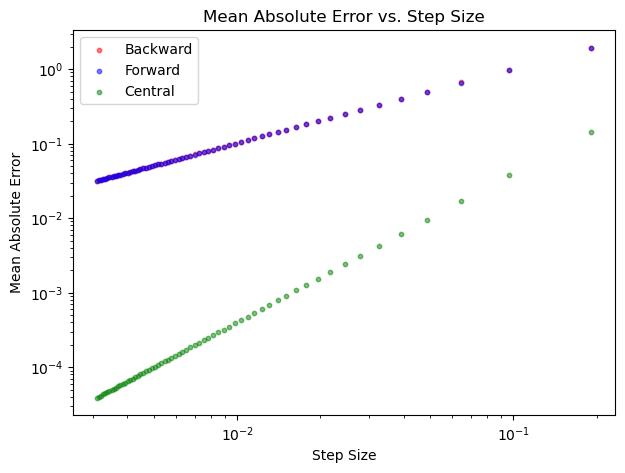

In [9]:
n = 64
x_5 = [np.linspace(0, 4 * np.pi, 64*k + 3) for k in range(n)]

step_sizes = [x[1] - x[0] for x in x_5][1:]

mae_forward = [mae(grid, 'forward') for grid in x_5][1:]
mae_backward = [mae(grid, 'backward') for grid in x_5][1:]
mae_central = [mae(grid, 'central') for grid in x_5][1:]


fig, maeplot = plt.subplots(figsize=(7, 5))
maeplot.scatter(step_sizes, mae_backward, c='red', s=10, alpha=0.5, label='Backward')
maeplot.scatter(step_sizes, mae_forward, c='blue', s=10, alpha=0.5, label='Forward')
maeplot.scatter(step_sizes, mae_central, c='green', s=10, alpha=0.5, label='Central')
maeplot.set_xscale('log')
maeplot.set_yscale('log')
maeplot.set_xlabel('Step Size')
maeplot.set_ylabel('Mean Absolute Error')
maeplot.set_title('Mean Absolute Error vs. Step Size')
maeplot.legend()
plt.show()

#### Problem 1 code summary

The code demonstrates different methods (using the given difference formulas) for graphing the first derivative of a function, which are then compared to one another. Additionally, graphs for different numbers of points are plotted. These results will allow us to understand the relationship between step size and the mean absolute error of each first-derivative method.

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [10]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)
print(x_roll2)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x)[:-1]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[ 2.  3.  4.  5.  6.  7.  8.  9. 10.  1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]
